# 方向二：省级医疗资源配置效率 DEA–KMeans 演示版

**角色定位：成员6（算法架构师）**
**当前任务：基于成员4整理好的省级医疗资源面板数据，搭建可运行的 DEA 演示流程。**

本 Notebook 是一个**算法流程验证版**，不是最终论文结果版。
目前可直接使用的数据主要包括两个投入指标：

- 卫生人员数量（万人）
- 医疗机构数量（个）

由于正式的产出端健康指标（如预期寿命、死亡率改善指标等）尚未全部接入，因此本 Notebook 先构造一个**临时伪产出变量**，用于验证以下流程是否能够顺利运行：

1. 读取省级医疗资源面板数据
2. 提取 2024 年横截面
3. 构造临时伪产出
4. 运行 DEA（CCR / BCC）
5. 进行 K-Means 聚类
6. 导出结果表和可视化图

> 说明：当前结果仅用于验证算法链路是否跑通，不应直接解释为最终政策结论。

## 1. 导入所需库并配置绘图环境

本部分用于导入数据处理、DEA 求解、聚类分析和绘图所需的 Python 库。

同时，为了避免 matplotlib 在 Windows 环境下出现中文标题、坐标轴标签、省份名称显示为方框的问题，这里统一设置中文字体。

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.optimize import linprog
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ===== Global plotting configuration =====
mpl.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "SimSun"]
mpl.rcParams["axes.unicode_minus"] = False

## 2. 设置数据路径与全局参数

本部分设置项目路径、输入数据路径、输出结果路径、分析年份、随机种子以及聚类类别数。

如果你的项目目录发生变化，只需要修改这里即可。

In [2]:
# ===== Paths and global parameters =====
BASE_DIR = Path(r"E:\2026_BigData_Project")
DATA_PATH = BASE_DIR / "data" / "processed" / "China_Province_Health_Panel.csv"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

YEAR_TO_USE = 2024
RANDOM_SEED = 42
N_CLUSTERS = 4

## 3. 读取成员4整理好的省级医疗资源面板数据

成员4交接的数据表应至少包含以下字段：

- 地区
- 年份
- 卫生人员数量(万人)
- 医疗机构数量(个)

本函数负责读取 CSV 文件，并检查关键字段是否齐全。

In [3]:
def load_data(csv_path: Path) -> pd.DataFrame:
    """读取成员4整理好的省级医疗资源面板数据。"""
    df = pd.read_csv(csv_path)

    required_cols = ["地区", "年份", "卫生人员数量(万人)", "医疗机构数量(个)"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"缺少必要字段: {missing}")

    return df

## 4. 提取 2024 年省级横截面数据

DEA 通常用于比较**同一时期内多个可比对象之间的相对效率**。

因此，这里先从 2005–2024 的省级面板数据中提取 **2024 年横截面**，并将每个省份视为一个 DMU（决策单元）。

In [4]:
def get_cross_section(df: pd.DataFrame, year: int = 2024) -> pd.DataFrame:
    """提取指定年份的横截面数据。"""
    sub = df[df["年份"] == year].copy()

    if sub.empty:
        raise ValueError(f"数据中不存在年份 {year}")

    sub = sub.sort_values("地区").reset_index(drop=True)
    return sub

## 5. 构造临时伪产出变量

目前正式的健康结果类产出指标尚未完全接入，因此为了先验证 DEA 的计算流程，这里构造一个**临时伪产出变量**。

需要强调的是：

- 该变量只用于测试 DEA 算法链路是否能够正常运行；
- 它不能代表最终论文中的正式健康产出指标；
- 后续接入真实输出变量后，可以直接替换这一部分。

为了避免伪产出与投入变量之间关系过于简单，这里先对投入变量进行标准化，并加入少量随机扰动。

In [5]:
def build_pseudo_output(df: pd.DataFrame, random_state: int = 42) -> pd.DataFrame:
    """
    构造 DEA 演示版使用的临时伪产出变量。

    说明：
    - 该变量与现有投入变量相关；
    - 但通过标准化和随机扰动避免形成过于机械的单调映射；
    - 仅用于算法流程测试，不用于正式结论。
    """
    rng = np.random.default_rng(random_state)

    x1 = df["卫生人员数量(万人)"].astype(float).values
    x2 = df["医疗机构数量(个)"].astype(float).values

    x1_std = (x1 - x1.mean()) / (x1.std() + 1e-9)
    x2_std = (x2 - x2.mean()) / (x2.std() + 1e-9)

    noise = rng.normal(0, 0.15, size=len(df))

    pseudo_output = 10 + 0.8 * x1_std + 0.3 * x2_std - 0.2 * (x2_std ** 2) + noise
    pseudo_output = pseudo_output - pseudo_output.min() + 1.0

    out = df.copy()
    out["伪产出"] = pseudo_output
    return out

## 6. DEA 求解器：输入导向包络模型

本部分实现 DEA 的核心求解过程。

这里采用的是**输入导向 DEA 模型**，其含义是：

> 在保持产出水平不低于当前对象的前提下，考察该对象的投入最多可以按比例压缩到多少。

这个压缩比例通常记为 **theta**，也就是 DEA 的效率值。

本 Notebook 同时考虑两种经典 DEA 假设：

- **CCR 模型**：固定规模报酬
- **BCC 模型**：变动规模报酬

In [6]:
def solve_dea_input_oriented(X: np.ndarray, Y: np.ndarray, rts: str = "bcc") -> np.ndarray:
    """
    输入导向 DEA 包络模型求解器。

    参数
    ----
    X : np.ndarray, shape (n_dmu, m_inputs)
        投入矩阵
    Y : np.ndarray, shape (n_dmu, s_outputs)
        产出矩阵
    rts : str
        "ccr" 表示固定规模报酬
        "bcc" 表示变动规模报酬

    返回
    ----
    eff_scores : np.ndarray
        DEA 效率值 theta，理论范围在 (0, 1]
    """
    n, m = X.shape
    _, s = Y.shape

    eff_scores = np.zeros(n)

    for o in range(n):
        # 变量顺序：[lambda_1, ..., lambda_n, theta]
        c = np.zeros(n + 1)
        c[-1] = 1.0  # 目标：最小化 theta

        A_ub = []
        b_ub = []

        # 输入约束：
        # sum_j lambda_j * x_ij - theta * x_io <= 0
        for i in range(m):
            row = np.zeros(n + 1)
            row[:n] = X[:, i]
            row[-1] = -X[o, i]
            A_ub.append(row)
            b_ub.append(0.0)

        # 输出约束：
        # -sum_j lambda_j * y_rj <= -y_ro
        for r in range(s):
            row = np.zeros(n + 1)
            row[:n] = -Y[:, r]
            row[-1] = 0.0
            A_ub.append(row)
            b_ub.append(-Y[o, r])

        A_eq = None
        b_eq = None

        # BCC 模型增加凸性约束：sum_j lambda_j = 1
        if rts.lower() == "bcc":
            A_eq = [np.r_[np.ones(n), 0.0]]
            b_eq = [1.0]

        bounds = [(0, None)] * n + [(0, 1)]

        res = linprog(
            c=c,
            A_ub=np.array(A_ub),
            b_ub=np.array(b_ub),
            A_eq=np.array(A_eq) if A_eq is not None else None,
            b_eq=np.array(b_eq) if b_eq is not None else None,
            bounds=bounds,
            method="highs"
        )

        if not res.success:
            print(f"[WARN] DMU {o} 求解失败: {res.message}")
            eff_scores[o] = np.nan
        else:
            eff_scores[o] = res.x[-1]

    return eff_scores

## 7. 同时运行 CCR 与 BCC 两种 DEA 模型

本函数负责整理投入矩阵和产出矩阵，并分别运行：

- CCR 效率
- BCC 效率

随后进一步计算：

- 规模效率 = CCR / BCC

其中：

- CCR 更强调综合技术效率；
- BCC 更强调纯技术效率；
- 规模效率反映效率损失中与规模因素相关的部分。

In [7]:
def run_dea(df: pd.DataFrame) -> pd.DataFrame:
    """在准备好的数据上运行 CCR 与 BCC DEA 模型。"""
    result = df.copy()

    X = result[["卫生人员数量(万人)", "医疗机构数量(个)"]].astype(float).values
    Y = result[["伪产出"]].astype(float).values

    # 为增强数值稳定性，对医疗机构数量做轻度缩放
    X_scaled = X.copy()
    X_scaled[:, 1] = X_scaled[:, 1] / 1000.0
    Y_scaled = Y.copy()

    eff_ccr = solve_dea_input_oriented(X_scaled, Y_scaled, rts="ccr")
    eff_bcc = solve_dea_input_oriented(X_scaled, Y_scaled, rts="bcc")

    result["DEA_CCR"] = eff_ccr
    result["DEA_BCC"] = eff_bcc
    result["规模效率"] = result["DEA_CCR"] / result["DEA_BCC"]

    return result

## 8. 基于 DEA 结果和投入指标进行 K-Means 聚类

在得到 DEA 效率值之后，本部分进一步进行初步聚类分析。

聚类所使用的特征包括：

- 卫生人员数量(万人)
- 医疗机构数量(个)
- DEA_BCC
- 规模效率

这一步的目标是为后续省份分型提供一个初步基础，例如：

- 高投入—高效率
- 高投入—低效率
- 低投入—高效率
- 低投入—低效率

In [8]:
def run_kmeans(df: pd.DataFrame, n_clusters: int = 4, random_state: int = 42) -> pd.DataFrame:
    """基于投入变量与 DEA 结果进行 K-Means 聚类。"""
    result = df.copy()

    features = result[[
        "卫生人员数量(万人)",
        "医疗机构数量(个)",
        "DEA_BCC",
        "规模效率"
    ]].astype(float)

    scaler = StandardScaler()
    X_std = scaler.fit_transform(features)

    model = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=20
    )
    result["Cluster"] = model.fit_predict(X_std)

    return result

## 9. 导出结果表并绘制散点图

本部分完成两个任务：

1. 将最终结果表保存为 CSV 文件；
2. 绘制 DEA–KMeans 演示散点图。

图中设置为：

- 横轴：卫生人员数量(万人)
- 纵轴：DEA_BCC 效率
- 颜色：聚类类别

该图主要用于组内展示和初步观察省份在“投入—效率”维度上的分布情况。

In [9]:
def save_results_table(df: pd.DataFrame, year: int, output_dir: Path) -> None:
    """将结果表保存为 CSV 文件。"""
    out_csv = output_dir / f"dea_demo_result_{year}.csv"
    df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    print(f"[OK] 结果表已保存: {out_csv}")


def plot_cluster_scatter(df: pd.DataFrame, year: int, output_dir: Path) -> None:
    """绘制 DEA–KMeans 演示散点图。"""
    plt.figure(figsize=(10, 6))

    for c in sorted(df["Cluster"].unique()):
        sub = df[df["Cluster"] == c]
        plt.scatter(
            sub["卫生人员数量(万人)"],
            sub["DEA_BCC"],
            label=f"Cluster {c}",
            alpha=0.8,
            s=90
        )

    for _, row in df.iterrows():
        plt.text(
            row["卫生人员数量(万人)"] + 0.5,
            row["DEA_BCC"],
            row["地区"],
            fontsize=9
        )

    plt.xlabel("卫生人员数量(万人)", fontsize=13)
    plt.ylabel("DEA_BCC 效率", fontsize=13)
    plt.title(f"{year}年 省级医疗资源 DEA-KMeans Demo", fontsize=16)
    plt.legend()
    plt.tight_layout()

    out_png = output_dir / f"dea_kmeans_scatter_{year}.png"
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[OK] 散点图已保存: {out_png}")

## 10. 运行完整的 DEA–KMeans 演示流程

下面按顺序执行整个分析流程：

1. 读取数据
2. 提取 2024 年横截面
3. 构造伪产出
4. 运行 DEA
5. 进行聚类
6. 输出结果

In [10]:
# 第一步：读取数据
df = load_data(DATA_PATH)
print("[INFO] 原始数据 shape =", df.shape)

# 第二步：提取横截面
cross = get_cross_section(df, YEAR_TO_USE)
print(f"[INFO] {YEAR_TO_USE} 年横截面 shape =", cross.shape)

# 第三步：构造伪产出
cross = build_pseudo_output(cross, random_state=RANDOM_SEED)
print("[INFO] 已生成伪产出列：伪产出")

# 第四步：运行 DEA
dea_result = run_dea(cross)
print("[INFO] DEA 求解完成")

# 第五步：运行聚类
final_result = run_kmeans(dea_result, n_clusters=N_CLUSTERS, random_state=RANDOM_SEED)
print("[INFO] K-Means 聚类完成")

[INFO] 原始数据 shape = (620, 4)
[INFO] 2024 年横截面 shape = (31, 4)
[INFO] 已生成伪产出列：伪产出
[INFO] DEA 求解完成
[INFO] K-Means 聚类完成


## 11. 查看 DEA 核心结果

这里先查看 DEA 输出的主要列，包括：

- DEA_CCR
- DEA_BCC
- 规模效率
- Cluster

In [11]:
final_result[["地区", "DEA_CCR", "DEA_BCC", "规模效率", "Cluster"]].head(10)

,地区,DEA_CCR,DEA_BCC,规模效率,Cluster
0,上海,1.000000,1.000000,1.000000,1
1,云南,0.430917,0.786908,0.547608,2
2,内蒙古,0.496020,0.945957,0.524358,3
3,北京,0.801266,1.000000,0.801266,1
4,吉林,0.409332,0.690489,0.592815,2
5,四川,0.273024,0.828935,0.329367,0
6,天津,0.893955,0.952323,0.938710,1
7,宁夏,1.000000,1.000000,1.000000,1
8,安徽,0.442924,0.890242,0.497533,3
9,山东,0.245484,0.788155,0.311467,0


## 12. 按 BCC 效率进行排序查看

该排序仅用于当前演示阶段的结果检查。

由于当前使用的仍是临时伪产出，因此这里的排名不能直接解释为各省正式医疗资源配置效率排名。

In [12]:
ranking = final_result.sort_values("DEA_BCC", ascending=False).reset_index(drop=True)
ranking[["地区", "DEA_BCC", "DEA_CCR", "规模效率", "Cluster"]].head(15)

,地区,DEA_BCC,DEA_CCR,规模效率,Cluster
0,广东,1.000000,0.345471,0.345471,0
1,山西,1.000000,0.428575,0.428575,3
2,浙江,1.000000,0.447262,0.447262,3
3,江苏,1.000000,0.447509,0.447509,3
4,上海,1.000000,1.000000,1.000000,1
5,北京,1.000000,0.801266,0.801266,1
6,宁夏,1.000000,1.000000,1.000000,1
7,黑龙江,1.000000,0.563338,0.563338,3
8,西藏,1.000000,1.000000,1.000000,1
9,青海,1.000000,1.000000,1.000000,1


## 13. 保存结果表并生成图形

[OK] 结果表已保存: E:\2026_BigData_Project\output\dea_demo_result_2024.csv


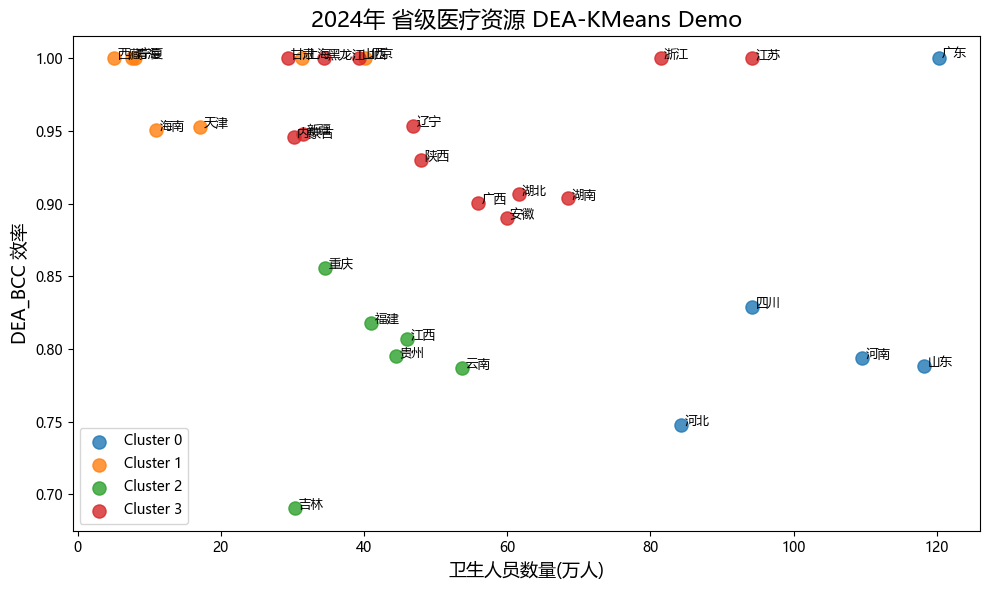

[OK] 散点图已保存: E:\2026_BigData_Project\output\dea_kmeans_scatter_2024.png


In [13]:
save_results_table(final_result, YEAR_TO_USE, OUTPUT_DIR)
plot_cluster_scatter(final_result, YEAR_TO_USE, OUTPUT_DIR)

## 14. 阶段性说明与后续改进方向

截至目前，本 Notebook 已经完成了以下算法链路的验证：

- 省级横截面提取
- 临时伪产出构造
- CCR / BCC DEA 求解
- 规模效率计算
- K-Means 聚类
- 结果导出与可视化

这说明方向二的核心算法框架已经初步打通。

但需要再次强调：

- 当前产出变量仍为临时伪产出；
- 当前结果仅适合用于流程演示和代码联调；
- 不应直接作为正式论文中的最终效率结论。

下一步应尽快接入真实健康结果指标，例如：

- 预期寿命
- 婴儿死亡率（经正向化处理）
- 孕产妇死亡率（经正向化处理）
- 其他健康结果类指标

一旦真实输出变量到位，本 Notebook 中的 DEA 框架可以直接复用，只需替换产出变量准备部分即可。